# Dynamic Asset Allocation under AI-Concentration Risk
## Markowitz vs Michaud Resampling vs Black-Litterman, evaluated through the 2026 AI/semiconductor crisis

**Course:** Financial Markets Analytics 2025/2026 — Final Project, Variant B (Dynamic Asset Allocation)

> Built on the same methodology as the course materials (`Markowitz_etf.ipynb`,
> `Black_Litterman.ipynb`, `Frontier_Robust.ipynb`), extended to a **rolling,
> out-of-sample, periodically-rebalanced** setting on a broader multi-asset ETF universe.

---

**Research question.** Since early 2025 the US equity market has become historically
concentrated around a handful of AI/mega-cap technology names, with AI-related stocks
driving the large majority of index gains. This concentration was stress-tested in **2026**:
a first warning shot on **5 February** (hyperscaler capex fears), a sharp leg down in
**early June** after a cautious AI-chip outlook from Broadcom and a hawkish Federal
Reserve repricing, and finally the **23–26 June global chip rout**, in which semiconductor
stocks lost more than **$1.3 trillion** of market value, South Korea's Kospi fell 10% in a
session and tripped a circuit breaker, and memory names (Micron, Samsung, SK Hynix) fell
12–13% in a day. Section 4 reconstructs the full timeline with sources.

This notebook asks:

> **Does resampled (Michaud) or Black–Litterman portfolio construction reduce unwanted
> concentration in AI/tech exposure relative to classical Markowitz, and does that
> translate into better risk-adjusted, out-of-sample performance through the 2026
> AI/semiconductor crisis?**

**Roadmap**
1. Setup and imports
2. Universe: a 19-ETF, 6-bucket multi-asset universe with an explicit AI/Tech cluster
3. Data download, inspection, cleaning — frozen to a parquet cache for reproducibility
4. **The 2026 AI/semiconductor crisis: timeline, narrative and a daily event study**
5. Monthly returns and correlation structure
6. Estimation choices: rolling window, covariance treatment (sample vs Ledoit–Wolf)
7. Optimization engine (long-only, capped, SLSQP) reused across strategies
8. Rolling, out-of-sample backtest engine (no look-ahead)
9. Strategy A: classical rolling Markowitz (max-Sharpe)
10. Strategy B: rolling Michaud resampling (Monte Carlo averaged weights)
11. Strategy C: rolling Black–Litterman with **three crisis-grounded views**
12. Benchmarks: 60/40, 1/N (universe index), and a passive 100% QQQ reference
13. Out-of-sample performance: equity curves, drawdown, volatility, Sharpe/Sortino, turnover
14. Equity curves, drawdown and rolling volatility
15. Concentration diagnostics: HHI and AI-cluster weight over time
16. Stress-window deep dive: February and June 2026 at monthly and daily resolution
17. Conclusions

**Reproducibility.** All prices are frozen in `data/cache/` (parquet). The first run
downloads via `yfinance` with a fixed sample end date; every later run reproduces the
same numbers offline. The Monte Carlo resampling uses a fixed seed. All subjective
parameters are explicit and documented where they are set.

## 1. Setup and imports

In [1]:
# On Colab only: uncomment to install the two non-preinstalled dependencies.
# Locally, use the project venv:  pip install -r requirements.txt
# !pip install -q yfinance scikit-learn pyarrow
import warnings
warnings.filterwarnings('ignore')

In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import minimize
from sklearn.covariance import LedoitWolf

np.random.seed(42)
plt.rcParams['figure.figsize'] = (11, 7)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
sns.set_style('whitegrid')

# Frozen data cache (reproducibility) and exported figures (report / slides)
CACHE_DIR = Path('data/cache')
FIG_DIR = Path('figures')
CACHE_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(exist_ok=True)

def save_show(name):
    '''Save the current figure to figures/<name>.png, then display it.'''
    plt.tight_layout()
    plt.savefig(FIG_DIR / f'{name}.png', dpi=150, bbox_inches='tight')
    plt.show()

## 2. ETF universe (19 names, 6 asset-class buckets)

**Why this universe.** We keep the multi-asset "skeleton" required by the assignment
(broad developed + emerging equity, government bonds short/long, IG and HY credit,
commodities/gold, real estate, cash proxy) and add a deliberate **AI/Tech cluster**
(`QQQ`, `SMH`, `XLK`, plus `EWT` and `EWY` for direct exposure to the Taiwanese and
Korean semiconductor supply chain that sits at the center of the AI trade). This lets the
optimizers *decide* how much AI-concentration risk to carry, which is exactly the
empirical question of this project.

**Why Yahoo Finance / `yfinance`.** Free, broadly used in the course materials, sufficient
history (>15y) for every name in this universe, and consistent with the baseline notebooks
so results are comparable. A Bloomberg/FactSet pull would be a natural robustness check if
available.

**Sample period.** We target the maximum common daily history across all 19 tickers,
required to be at least 15 years; see the cleaning step below for the exact aligned
window.

In [3]:
tickers = {
    # --- Broad / diversified equity ---
    'SPY':  'US Large Cap Equity',
    'IWM':  'US Small Cap Equity',
    'EFA':  'Developed ex-US Equity',
    'EEM':  'Emerging Markets Equity',
    # --- AI / Tech concentration cluster ---
    'QQQ':  'Nasdaq 100 (Mega-cap / AI Tech)',
    'SMH':  'Semiconductors',
    'XLK':  'US Technology Sector',
    'EWT':  'Taiwan Equity (semiconductor supply chain)',
    'EWY':  'South Korea Equity (memory chip supply chain)',
    # --- Government bonds ---
    'SHY':  'US Treasury 1-3y',
    'IEF':  'US Treasury 7-10y',
    'TLT':  'US Treasury 20+y',
    'TIP':  'US TIPS (inflation-linked)',
    # --- Credit ---
    'LQD':  'US Investment Grade Corporate',
    'HYG':  'US High Yield Corporate',
    # --- Real assets ---
    'GLD':  'Gold',
    'DBC':  'Broad Commodities',
    'VNQ':  'US Real Estate (REIT)',
    # --- Cash proxy ---
    'BIL':  'US T-Bill 1-3m (cash proxy)',
}
asset_names = list(tickers.keys())
n = len(asset_names)

# Asset-class buckets: used later for concentration diagnostics (HHI), for the
# Black-Litterman equilibrium prior, and as an optional budget-constraint layer
asset_class = {
    'SPY': 'Equity_Broad', 'IWM': 'Equity_Broad', 'EFA': 'Equity_Broad', 'EEM': 'Equity_Broad',
    'QQQ': 'Equity_AI_Tech', 'SMH': 'Equity_AI_Tech', 'XLK': 'Equity_AI_Tech',
    'EWT': 'Equity_AI_Tech', 'EWY': 'Equity_AI_Tech',
    'SHY': 'Govt_Bonds', 'IEF': 'Govt_Bonds', 'TLT': 'Govt_Bonds', 'TIP': 'Govt_Bonds',
    'LQD': 'Credit', 'HYG': 'Credit',
    'GLD': 'Real_Assets', 'DBC': 'Real_Assets', 'VNQ': 'Real_Assets',
    'BIL': 'Cash',
}
bucket_members = {b: [t for t in asset_names if asset_class[t] == b] for b in sorted(set(asset_class.values()))}

pd.DataFrame({
    'Asset class': [tickers[t] for t in asset_names],
    'Bucket': [asset_class[t] for t in asset_names],
}, index=asset_names)

,Asset class,Bucket
SPY,US Large Cap Equity,Equity_Broad
IWM,US Small Cap Equity,Equity_Broad
EFA,Developed ex-US Equity,Equity_Broad
EEM,Emerging Markets Equity,Equity_Broad
QQQ,Nasdaq 100 (Mega-cap / AI Tech),Equity_AI_Tech
SMH,Semiconductors,Equity_AI_Tech
XLK,US Technology Sector,Equity_AI_Tech
EWT,Taiwan Equity (semiconductor supply chain),Equity_AI_Tech
EWY,South Korea Equity (memory chip supply chain),Equity_AI_Tech
SHY,US Treasury 1-3y,Govt_Bonds


## 3. Data download, inspection and cleaning

We pull daily adjusted prices over a **fixed, explicit sample window** — `2010-07-01` to
`2026-06-30` (≈16 years, a 1-year buffer above the 15-year minimum required by the
assignment, and ending with the last complete month after the June 2026 crisis). Fixing
the end date, instead of using a rolling `period='16y'`, means the analysis does not
silently change every time the notebook is re-run.

**Caching.** The first run downloads from Yahoo Finance and freezes the panel to
`data/cache/prices_daily.parquet`; later runs load the cache and are fully reproducible
offline. Delete the file to force a fresh download.

We then inspect coverage per ticker and align the panel to the **maximum common start
date**, so every strategy is estimated and backtested on a perfectly synchronized panel.
This is the documented cleaning step required by the assignment.

In [4]:
SAMPLE_START = '2010-07-01'   # fixed sample window -- subjective choice, documented above
SAMPLE_END = '2026-06-30'     # last complete month after the June 2026 crisis

cache_file = CACHE_DIR / 'prices_daily.parquet'
if cache_file.exists():
    prices_daily = pd.read_parquet(cache_file)
    print(f'Loaded frozen prices from {cache_file}')
else:
    raw = yf.download(asset_names, start=SAMPLE_START, end=pd.Timestamp(SAMPLE_END) + pd.Timedelta(days=1),
                      auto_adjust=True, progress=False)
    prices_daily = raw['Close'] if isinstance(raw.columns, pd.MultiIndex) else raw
    prices_daily = prices_daily[asset_names]
    prices_daily.to_parquet(cache_file)
    print(f'Downloaded and froze prices to {cache_file}')

print()
print('Raw daily observation count per ticker:')
print(prices_daily.count())
print()
print('First valid date per ticker:')
print(prices_daily.apply(lambda s: s.first_valid_index()))

Loaded frozen prices from data\cache\prices_daily.parquet

Raw daily observation count per ticker:
Ticker
SPY    4023
IWM    4023
EFA    4023
EEM    4023
QQQ    4023
SMH    4023
XLK    4023
EWT    4023
EWY    4023
SHY    4023
IEF    4023
TLT    4023
TIP    4023
LQD    4023
HYG    4023
GLD    4023
DBC    4023
VNQ    4023
BIL    4023
dtype: int64

First valid date per ticker:
Ticker
SPY   2010-07-01
IWM   2010-07-01
EFA   2010-07-01
EEM   2010-07-01
QQQ   2010-07-01
SMH   2010-07-01
XLK   2010-07-01
EWT   2010-07-01
EWY   2010-07-01
SHY   2010-07-01
IEF   2010-07-01
TLT   2010-07-01
TIP   2010-07-01
LQD   2010-07-01
HYG   2010-07-01
GLD   2010-07-01
DBC   2010-07-01
VNQ   2010-07-01
BIL   2010-07-01
dtype: datetime64[ms]


In [5]:
# --- Cleaning: align to the maximum common start date, then drop any residual NaN ---
first_valid = prices_daily.apply(lambda s: s.first_valid_index())
common_start = first_valid.max()
print(f'Latest "first valid date" across the universe: {common_start.date()}  (driven by {first_valid.idxmax()})')

prices_daily = prices_daily.loc[common_start:].dropna()
n_years = (prices_daily.index.max() - prices_daily.index.min()).days / 365.25
print(f'Aligned sample: {prices_daily.index.min().date()} -> {prices_daily.index.max().date()}')
print(f'Daily observations after cleaning: {len(prices_daily)}  (~{n_years:.1f} years)')
assert n_years >= 15, 'Sample shorter than 15 years -- drop the newest ETF and re-run.'

Latest "first valid date" across the universe: 2010-07-01  (driven by SPY)
Aligned sample: 2010-07-01 -> 2026-06-30
Daily observations after cleaning: 4023  (~16.0 years)


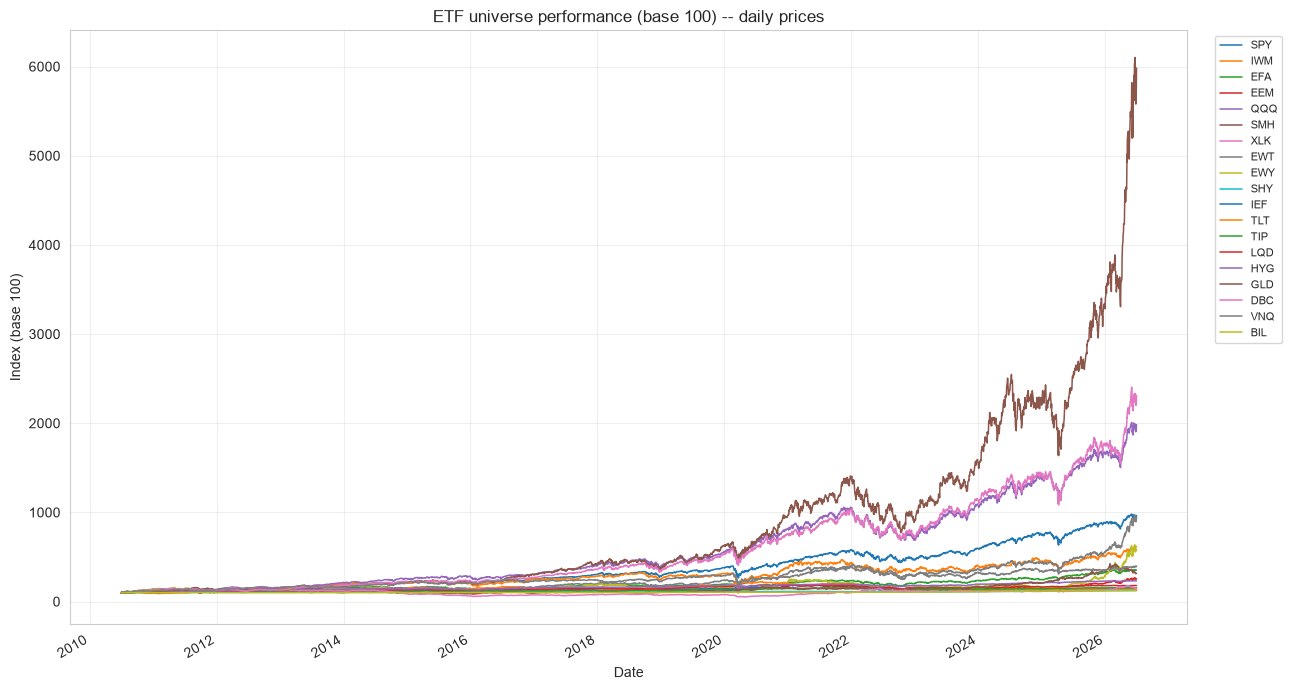

In [6]:
# Quick visual inspection: normalized prices (base 100)
(prices_daily / prices_daily.iloc[0] * 100).plot(figsize=(13, 7), lw=1.1,
    title='ETF universe performance (base 100) -- daily prices')
plt.ylabel('Index (base 100)')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
save_show('01_universe_normalized_prices')

## 4. The 2026 AI/semiconductor crisis: timeline, narrative and event study

Before modelling anything, we reconstruct **what actually happened** — the crisis is the
empirical laboratory of this project, so it deserves to be documented properly.

### 4.1 Background: the AI-concentration build-up (2023–2025)

From the launch of large-scale generative AI in 2023 through 2025, index gains became
extraordinarily concentrated: a handful of AI/mega-cap technology names came to represent
an unprecedented share of the S&P 500, hyperscalers announced capital-expenditure plans
without precedent in corporate history (Amazon guided to **more than $200bn** of capex for
2026, up ~53% year-on-year; Alphabet and Meta nearly doubled theirs), and the memory/foundry
supply chain — TSMC in Taiwan, Samsung and SK Hynix in Korea, Micron in the US — became the
physical bottleneck of the AI trade. By mid-2026, **Samsung and SK Hynix alone accounted for
roughly half of the Kospi's market capitalisation** and supplied about 70% of its 2026 gains:
concentration was not only a US phenomenon, it was global and it ran through the
semiconductor supply chain.

### 4.2 Timeline of the 2026 stress episodes

| Date | Event | Market impact |
|---|---|---|
| **5 Feb 2026** | *Preview episode*: investors take fright at hyperscaler AI capex guidance; SaaS names (Salesforce, ServiceNow, Adobe) sold on AI-disruption fears | Nasdaq −1.59%, S&P 500 −1.23%, Dow −1.20% |
| **early Jun 2026** | Broadcom issues a cautious AI-chip outlook; markets reprice the Fed under new chair Kevin Warsh (+50bp of hikes by December priced in, double two weeks earlier) | 5 Jun: Nasdaq 100 −5%, worst day of the year |
| **23 Jun 2026** | *Global chip rout*: selloff sweeps from Asia through Europe to the US | Kospi −10%, circuit breaker tripped (4th of the year); Samsung −12%, SK Hynix −12%; Micron −13%, Sandisk −13%, Qualcomm −8%, AMD −6%, Intel −6%; Nasdaq −2.2%, S&P −1.44% |
| **24 Jun 2026** | Rout deepens; semiconductor stocks have lost **> $1.3 trillion** of market value; Nasdaq > 6% below its 2 Jun all-time high | Nasdaq ~−4% in the session |
| **25 Jun 2026** | Micron reports blowout FQ3 earnings (revenue $41.5bn, ~4× year-on-year) on AI memory demand | Micron +16%; Kospi +5% at the open, SK Hynix +10%, Samsung +5% |

### 4.3 The three structural drivers

1. **Stretched AI valuations meet higher rates.** The AI infrastructure build-out was
   increasingly *debt-funded*; the hawkish Fed repricing (rate *hikes*, not cuts, priced
   under the new chair) mechanically challenged the discounted value of long-duration
   AI cash flows.
2. **Memory-chip price crisis and weak end-demand.** A deepening memory pricing crisis and a
   projected collapse in global smartphone demand undermined the non-AI part of chipmakers'
   revenue, exactly while their valuations priced AI perfection.
3. **Concentration itself.** With two names ≈ half the Kospi and the AI cluster an
   unprecedented share of US indices, there was no index-level diversification left when the
   cluster repriced — the textbook case for the *portfolio-construction* question this
   project studies.

**Sources.** CNN Business ([23 Jun](https://www.cnn.com/2026/06/23/business/stock-market-kospi-dow-nasdaq-ai),
[26 Jun](https://www.cnn.com/2026/06/26/investing/tech-stocks-nasdaq-kospi)),
[CNBC 23 Jun](https://www.cnbc.com/2026/06/23/tech-stocks-sell-off-mag7-samsung-sk-hynix.html),
[NPR 23 Jun](https://www.npr.org/2026/06/23/nx-s1-5867633/ai-selloff-tech-stocks-bubble-nasdaq),
[Washington Post 23 Jun](https://www.washingtonpost.com/business/2026/06/23/big-tech-losses-fuel-global-stock-market-sell-off/),
[Yahoo Finance](https://finance.yahoo.com/technology/articles/global-chip-stocks-slump-rate-091128932.html),
Investing.com ([memory rally](https://www.investing.com/analysis/is-the-memory-rally-still-alive-after-the-semiconductor-selloff-200683218),
[chip selloff](https://www.investing.com/analysis/the-chip-selloff-is-not-just-about-ai-theres-a-bigger-problem-under-the-hood-200682649)).

### 4.4 What this implies for the portfolio experiment

The crisis gives us (i) **two dated stress windows** for out-of-sample evaluation, and
(ii) an economically grounded basis for the **Black–Litterman views** in Section 11:
a cautionary view on the AI/Tech cluster (driver 1), a view on the memory supply chain
(driver 2, expressed through `EWY`/`EWT` vs US mega-cap tech), and a duration view
(driver 1, expressed through `SHY` vs `TLT`). The event study below verifies, at daily
frequency, how each corner of our ETF universe actually behaved in the stress windows.

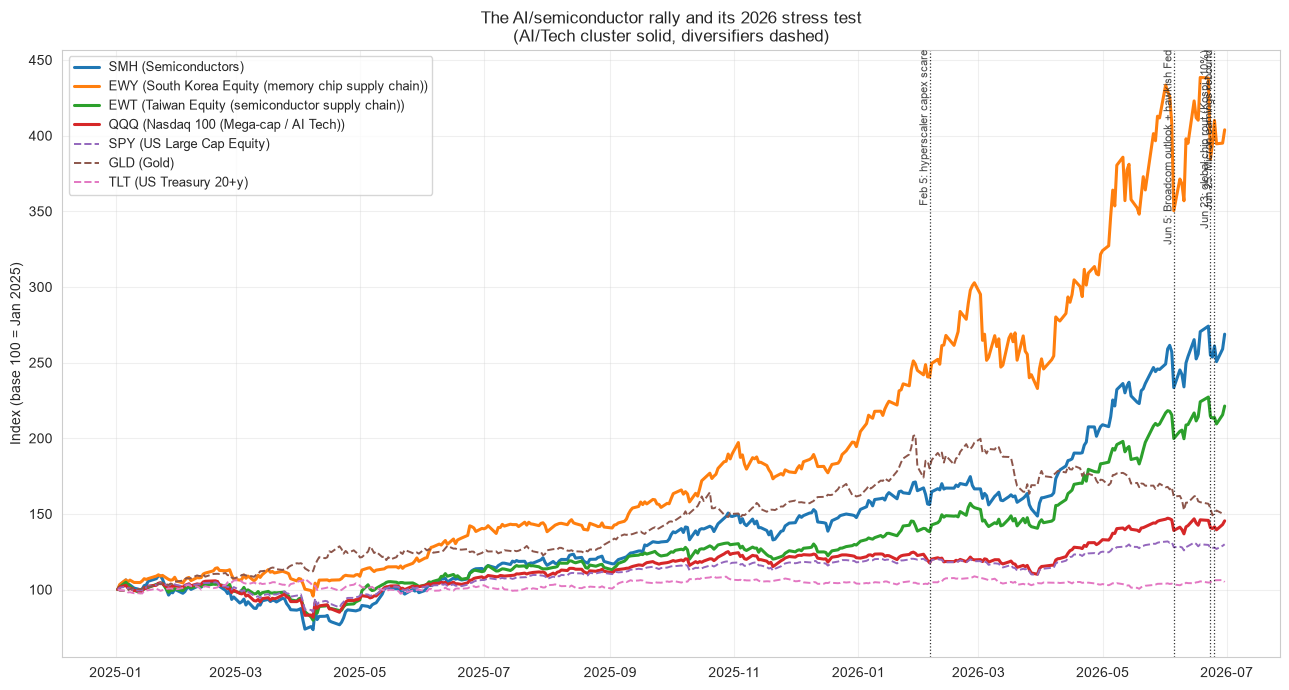

In [7]:
# Dated crisis events (used for chart annotations and stress windows throughout)
CRISIS_EVENTS = {
    '2026-02-05': 'Feb 5: hyperscaler capex scare',
    '2026-06-05': 'Jun 5: Broadcom outlook + hawkish Fed',
    '2026-06-23': 'Jun 23: global chip rout (Kospi -10%)',
    '2026-06-25': 'Jun 25: Micron earnings rebound',
}

# Event-study stress windows (daily resolution)
EVENT_WINDOWS = {
    'Feb 2026 preview (2-13 Feb)':      ('2026-02-02', '2026-02-13'),
    'Early-June leg (1-12 Jun)':        ('2026-06-01', '2026-06-12'),
    'Global chip rout (22-30 Jun)':     ('2026-06-22', '2026-06-30'),
    'Full June episode (1-30 Jun)':     ('2026-06-01', '2026-06-30'),
}

# Long view: the AI rally of 2025 and its 2026 stress test, with events annotated
focus = ['SMH', 'EWY', 'EWT', 'QQQ', 'SPY', 'GLD', 'TLT']
px = prices_daily.loc['2025-01-01':, focus]
norm = px / px.iloc[0] * 100

fig, ax = plt.subplots(figsize=(13, 7))
for tkr in focus:
    lw = 2.2 if asset_class[tkr] == 'Equity_AI_Tech' else 1.4
    ls = '-' if asset_class[tkr] == 'Equity_AI_Tech' else '--'
    ax.plot(norm.index, norm[tkr], lw=lw, ls=ls, label=f'{tkr} ({tickers[tkr]})')
for d, lbl in CRISIS_EVENTS.items():
    ax.axvline(pd.Timestamp(d), color='black', lw=0.9, ls=':', alpha=0.8)
    ax.annotate(lbl, xy=(pd.Timestamp(d), ax.get_ylim()[1]), fontsize=8, rotation=90,
                va='top', ha='right', alpha=0.85)
ax.set_ylabel('Index (base 100 = Jan 2025)')
ax.set_title('The AI/semiconductor rally and its 2026 stress test\n(AI/Tech cluster solid, diversifiers dashed)')
ax.legend(loc='upper left', fontsize=9)
save_show('02_crisis_timeline_annotated')

In [8]:
# Event study: cumulative simple return of every ETF in each stress window,
# grouped by asset-class bucket. This documents which corners of the universe
# actually diversified the AI shock (and which did not).
daily_simple = prices_daily.pct_change().dropna()

def window_cum_return(start, end):
    r = daily_simple.loc[start:end]
    return (1 + r).prod() - 1

event_table = pd.DataFrame({name: window_cum_return(s, e) for name, (s, e) in EVENT_WINDOWS.items()})
event_table.insert(0, 'Bucket', [asset_class[t] for t in event_table.index])
event_table = event_table.sort_values('Bucket')

styled = (event_table.style
          .format('{:+.2%}', subset=list(EVENT_WINDOWS.keys()))
          .background_gradient(cmap='RdYlGn', vmin=-0.15, vmax=0.15, subset=list(EVENT_WINDOWS.keys())))
display(styled)

# Bucket-level averages: the summary view for the presentation
bucket_table = event_table.groupby('Bucket')[list(EVENT_WINDOWS.keys())].mean()
print('Average cumulative return per asset-class bucket:')
display(bucket_table.style.format('{:+.2%}').background_gradient(cmap='RdYlGn', vmin=-0.12, vmax=0.12))

,Bucket,Feb 2026 preview (2-13 Feb),Early-June leg (1-12 Jun),Global chip rout (22-30 Jun),Full June episode (1-30 Jun)
Ticker,,,,,
BIL,Cash,+0.15%,+0.13%,+0.08%,+0.27%
LQD,Credit,+1.30%,+0.06%,+0.00%,+0.11%
HYG,Credit,+0.16%,+0.05%,-0.05%,+0.09%
QQQ,Equity_AI_Tech,-3.21%,-2.30%,-0.46%,-0.15%
SMH,Equity_AI_Tech,+1.06%,+3.51%,-0.60%,+9.51%
XLK,Equity_AI_Tech,-3.00%,-3.26%,-0.36%,-0.14%
EWT,Equity_AI_Tech,+7.33%,-0.16%,-1.25%,+5.67%
EWY,Equity_AI_Tech,+9.44%,-4.07%,-7.89%,-1.91%
SPY,Equity_Broad,-1.48%,-1.95%,+0.00%,-1.03%


Average cumulative return per asset-class bucket:


,Feb 2026 preview (2-13 Feb),Early-June leg (1-12 Jun),Global chip rout (22-30 Jun),Full June episode (1-30 Jun)
Bucket,,,,
Cash,+0.15%,+0.13%,+0.08%,+0.27%
Credit,+0.73%,+0.05%,-0.02%,+0.10%
Equity_AI_Tech,+2.32%,-1.25%,-2.11%,+2.60%
Equity_Broad,+1.67%,-0.48%,-0.56%,+0.90%
Govt_Bonds,+1.56%,-0.01%,+0.01%,+0.26%
Real_Assets,+1.96%,-2.52%,-2.18%,-6.53%


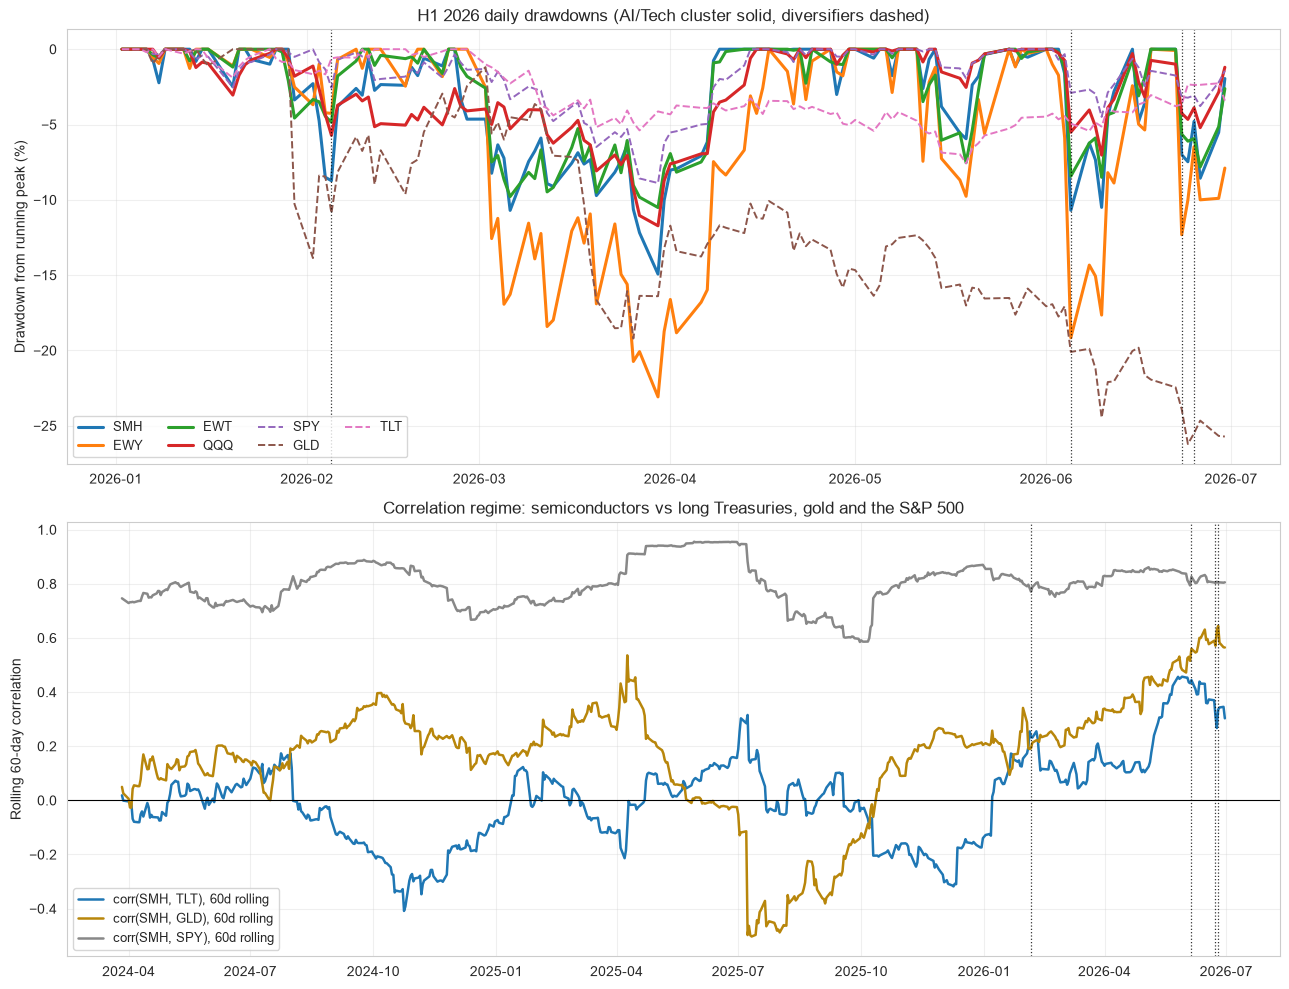

In [9]:
# H1-2026 zoom (drawdown from the 2 June peak) + correlation regime check
fig, axes = plt.subplots(2, 1, figsize=(13, 10))

# (a) Daily drawdown through H1 2026 for the AI cluster vs diversifiers
px26 = prices_daily.loc['2026-01-01':, focus]
dd26 = px26 / px26.cummax() - 1
for tkr in focus:
    lw = 2.2 if asset_class[tkr] == 'Equity_AI_Tech' else 1.4
    ls = '-' if asset_class[tkr] == 'Equity_AI_Tech' else '--'
    axes[0].plot(dd26.index, dd26[tkr] * 100, lw=lw, ls=ls, label=tkr)
for d in CRISIS_EVENTS:
    axes[0].axvline(pd.Timestamp(d), color='black', lw=0.9, ls=':', alpha=0.8)
axes[0].set_ylabel('Drawdown from running peak (%)')
axes[0].set_title('H1 2026 daily drawdowns (AI/Tech cluster solid, diversifiers dashed)')
axes[0].legend(loc='lower left', fontsize=9, ncol=4)

# (b) Rolling 60-day correlation of SMH vs the classic diversifiers:
# did bonds and gold still hedge the AI trade when it mattered?
roll = daily_simple.loc['2024-01-01':]
for other, color in [('TLT', '#1f77b4'), ('GLD', '#b8860b'), ('SPY', '#888888')]:
    rc = roll['SMH'].rolling(60).corr(roll[other])
    axes[1].plot(rc.index, rc, lw=1.8, label=f'corr(SMH, {other}), 60d rolling', color=color)
for d in CRISIS_EVENTS:
    axes[1].axvline(pd.Timestamp(d), color='black', lw=0.9, ls=':', alpha=0.8)
axes[1].axhline(0, color='black', lw=0.8)
axes[1].set_ylabel('Rolling 60-day correlation')
axes[1].set_title('Correlation regime: semiconductors vs long Treasuries, gold and the S&P 500')
axes[1].legend(loc='lower left', fontsize=9)
save_show('03_event_study_drawdown_correlation')

## 5. Monthly returns

As in the baseline course notebook, we resample to **month-end** and use monthly log
returns for estimation: closer to i.i.d./normal, less microstructure noise, and a more
robust x12 / sqrt(12) annualization than daily-based estimates. Because the sample ends on
`2026-06-30`, every monthly observation is a complete month.

In [10]:
monthly_prices = prices_daily.resample('ME').last()
rets_m = np.log(monthly_prices / monthly_prices.shift(1)).dropna()
MONTHS_PER_YEAR = 12
T = len(rets_m)
print(f'Monthly observations: {T}  ({rets_m.index.min().date()} -> {rets_m.index.max().date()})')
rets_m.tail()

Monthly observations: 191  (2010-08-31 -> 2026-06-30)


Ticker,SPY,IWM,EFA,EEM,QQQ,SMH,XLK,EWT,EWY,SHY,IEF,TLT,TIP,LQD,HYG,GLD,DBC,VNQ,BIL
Date,,,,,,,,,,,,,,,,,,,
2026-02-28,-0.008680,0.006756,0.045030,0.057215,-0.023725,0.007187,-0.036234,0.105992,0.212351,0.005304,0.024400,0.045296,0.012592,0.013686,-0.000012,0.083606,0.027056,0.052455,0.002667
2026-03-31,-0.050640,-0.050884,-0.081523,-0.097086,-0.049592,-0.058185,-0.041906,-0.064829,-0.207461,-0.004676,-0.023475,-0.043221,-0.013679,-0.020946,-0.009582,-0.117109,0.142702,-0.065221,0.002874
2026-04-30,0.099893,0.114084,0.052055,0.119367,0.145745,0.278880,0.182447,0.236923,0.267647,0.001905,-0.001504,-0.008432,0.010815,0.002815,0.015092,-0.015528,0.071638,0.082520,0.002885
2026-05-31,0.051288,0.043849,0.023949,0.069566,0.100465,0.167186,0.180334,0.134115,0.247138,0.000766,-0.000190,0.005320,0.001899,0.008587,0.004355,-0.015557,-0.053496,-0.006562,0.003169
2026-06-30,-0.010346,0.036294,0.006883,0.002411,-0.001492,0.090848,-0.001429,0.055173,-0.019278,0.000646,0.002509,0.011592,-0.004577,0.001128,0.000863,-0.124259,-0.100548,0.016374,0.002721


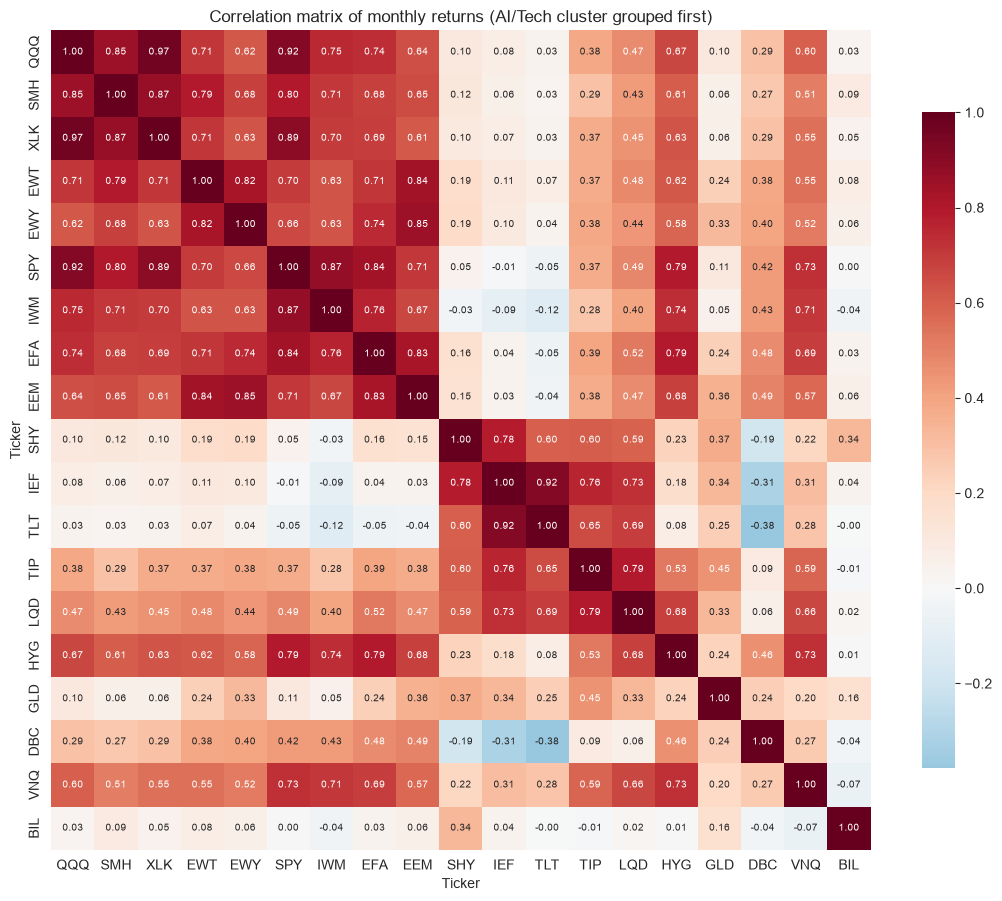

In [11]:
# Correlation matrix, with the AI/Tech cluster visually grouped first
ordered_cols = bucket_members['Equity_AI_Tech'] + [t for t in asset_names if asset_class[t] != 'Equity_AI_Tech']
corr = rets_m[ordered_cols].corr()
plt.figure(figsize=(11, 9))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, square=True,
            cbar_kws={'shrink': 0.8}, annot_kws={'fontsize': 7})
plt.title('Correlation matrix of monthly returns (AI/Tech cluster grouped first)')
save_show('04_correlation_matrix')

## 6. Estimation choices (the subjective parameters, made explicit)

- **Rolling window** for `mu`/`Sigma` estimation: `WINDOW_MONTHS = 60` (5 years). A shorter
  window reacts faster to regime change (like the AI buildout) but is noisier; a longer
  window is more stable but slower to reflect the new regime. The sensitivity notebook
  (`02_sensitivity_analysis.ipynb`) re-runs everything with 36 and 84 months.
- **Rebalancing frequency**: `REBAL_EVERY = 1` (monthly). Set to 3 for quarterly (also in
  the sensitivity notebook).
- **Covariance treatment**: `COV_METHOD = 'lw'` (Ledoit-Wolf shrinkage). This universe
  contains several highly correlated names by construction (`QQQ`, `SMH`, `XLK` all load
  heavily on the same AI factor), which makes the raw sample covariance matrix
  ill-conditioned on a 5-year monthly window (60 observations, 19 assets). Shrinkage keeps
  the optimizer numerically stable and is the fairer baseline for comparing Markowitz vs
  Michaud (otherwise Markowitz instability is partly a covariance-estimation artifact
  rather than a genuine mean-estimation one).
- **Constraints**: long-only, no leverage, `W_CAP = 0.30` maximum weight per single ETF.

In [12]:
def estimate_mu_sigma(window_rets, method='lw'):
    '''Annualized (mu, Sigma) estimated from a trailing window of monthly log returns.'''
    mu_hat = window_rets.mean().values * MONTHS_PER_YEAR
    if method == 'sample':
        Sigma_hat = window_rets.cov().values * MONTHS_PER_YEAR
    elif method == 'lw':
        lw = LedoitWolf().fit(window_rets.values)
        Sigma_hat = lw.covariance_ * MONTHS_PER_YEAR
    else:
        raise ValueError("method must be 'sample' or 'lw'")
    return mu_hat, Sigma_hat

COV_METHOD = 'lw'      # 'sample' or 'lw'  -- subjective choice, documented above
WINDOW_MONTHS = 60      # 5-year rolling estimation window -- subjective choice
REBAL_EVERY = 1         # 1 = monthly, 3 = quarterly -- subjective choice
W_CAP = 0.30            # long-only weight cap per single ETF -- subjective choice

## 7. Optimization engine

Same SLSQP machinery as the baseline notebooks. We implement the classical Markowitz
strategy as the **long-only, capped, maximum-Sharpe** portfolio (one of the three variants
suggested by the assignment; min-variance or a target-volatility grid are direct
alternatives using the same helpers). The Sharpe objective is computed gross of the
risk-free rate (`rf = 0` in the optimizer): with `BIL` investable in the universe the
optimizer can already allocate to cash directly, and the *reported* Sharpe ratios in
Section 13 are computed properly in excess of the realized T-bill return.

In [13]:
def portfolio_variance(w, S):
    return w @ S @ w

def neg_sharpe(w, mu_v, S):
    return -(w @ mu_v) / np.sqrt(w @ S @ w)

def max_sharpe_weights(mu_v, S, w_cap=None):
    if w_cap is None:
        w_cap = W_CAP
    n_ = len(mu_v)
    w0 = np.ones(n_) / n_
    cons = [{'type': 'eq', 'fun': lambda w: np.sum(w) - 1}]
    bounds = [(0.0, w_cap)] * n_
    res = minimize(neg_sharpe, w0, args=(mu_v, S), method='SLSQP',
                   bounds=bounds, constraints=cons,
                   options={'ftol': 1e-10, 'maxiter': 500})
    return res.x if res.success else np.ones(n_) / n_   # fallback: equal weight

def min_var_weights(mu_v, S, w_cap=None):
    if w_cap is None:
        w_cap = W_CAP
    n_ = len(mu_v)
    w0 = np.ones(n_) / n_
    cons = [{'type': 'eq', 'fun': lambda w: np.sum(w) - 1}]
    bounds = [(0.0, w_cap)] * n_
    res = minimize(portfolio_variance, w0, args=(S,), method='SLSQP',
                   bounds=bounds, constraints=cons,
                   options={'ftol': 1e-10, 'maxiter': 500})
    return res.x if res.success else np.ones(n_) / n_

## 8. Rolling, out-of-sample backtest engine

At each rebalancing date `t`, weights are computed using **only** information available up
to `t` (the trailing `WINDOW_MONTHS` window), then held and applied to the **realized**
returns of the following period(s) until the next rebalance. This is the no-look-ahead
discipline required by the assignment; a sanity check below verifies it explicitly.

In [14]:
rebalance_idx = list(range(WINDOW_MONTHS, T, REBAL_EVERY))
rebalance_dates = rets_m.index[rebalance_idx]
print(f'{len(rebalance_dates)} rebalancing dates, from {rebalance_dates[0].date()} to {rebalance_dates[-1].date()}')
print(f'(the first {WINDOW_MONTHS} months are used only to estimate mu/Sigma for the first rebalance)')

131 rebalancing dates, from 2015-08-31 to 2026-06-30
(the first 60 months are used only to estimate mu/Sigma for the first rebalance)


In [15]:
# No-look-ahead sanity check: for every rebalance, the last month used for
# estimation must come strictly BEFORE the first month the weights are applied to.
for j, t_idx in enumerate(rebalance_idx):
    est_window = rets_m.iloc[t_idx - WINDOW_MONTHS: t_idx]
    first_applied = rets_m.index[t_idx]
    assert est_window.index[-1] < first_applied, f'Look-ahead at rebalance {j}!'
print(f'OK: all {len(rebalance_idx)} rebalances use strictly past information.')
print(f'Example (first rebalance): estimate on {rets_m.index[rebalance_idx[0]-WINDOW_MONTHS].date()}'
      f' -> {rets_m.index[rebalance_idx[0]-1].date()}, apply from {rets_m.index[rebalance_idx[0]].date()}')

OK: all 131 rebalances use strictly past information.
Example (first rebalance): estimate on 2010-08-31 -> 2015-07-31, apply from 2015-08-31


In [16]:
def run_rolling_backtest(strategy_fn, name, **kwargs):
    '''Generic rolling engine, reused by every strategy below.'''
    W_hist = pd.DataFrame(index=rebalance_dates, columns=asset_names, dtype=float)
    port_rets = pd.Series(index=rets_m.index, dtype=float)

    for j, t_idx in enumerate(rebalance_idx):
        window = rets_m.iloc[t_idx - WINDOW_MONTHS: t_idx]
        mu_hat, Sigma_hat = estimate_mu_sigma(window, method=COV_METHOD)
        w = strategy_fn(mu_hat, Sigma_hat, **kwargs)
        W_hist.iloc[j] = w

        start = t_idx
        end = rebalance_idx[j + 1] if j + 1 < len(rebalance_idx) else T
        for k in range(start, end):
            port_rets.iloc[k] = rets_m.iloc[k].values @ w

    port_rets = port_rets.dropna()
    print(f'{name}: backtested {len(port_rets)} monthly periods over {len(rebalance_dates)} rebalances')
    return W_hist, port_rets

## 9. Strategy A -- classical rolling Markowitz (max-Sharpe, long-only, capped)

In [17]:
def strategy_markowitz(mu_hat, Sigma_hat):
    return max_sharpe_weights(mu_hat, Sigma_hat)

W_mkw, ret_mkw = run_rolling_backtest(strategy_markowitz, 'Classical Markowitz')

Classical Markowitz: backtested 131 monthly periods over 131 rebalances


## 10. Strategy B -- Michaud resampled frontier (rolling)

At each rebalance date we simulate `B_PATHS` alternative monthly-return histories from
`N(mu_hat/12, Sigma_hat/12)`, re-estimate `(mu_b, Sigma_b)` on each simulated history,
solve the same max-Sharpe problem on each, and **average the resulting weights**. This
directly targets estimation risk in `mu_hat` -- the dominant source of Markowitz
instability -- rather than the covariance matrix, which is already being shrunk.

In [18]:
B_PATHS = 300   # number of Monte Carlo resamples per rebalance -- subjective choice
                # (300-1000 is typical; kept moderate here for runtime; try 1000 for a
                # smoother -- but slower -- averaged frontier)

def strategy_michaud(mu_hat, Sigma_hat, B=B_PATHS, T_sim=WINDOW_MONTHS):
    mu_m = mu_hat / MONTHS_PER_YEAR
    S_m = Sigma_hat / MONTHS_PER_YEAR
    W_sim = np.zeros((B, n))
    for b in range(B):
        sim = np.random.multivariate_normal(mu_m, S_m, size=T_sim)
        mu_b = sim.mean(axis=0) * MONTHS_PER_YEAR
        S_b = np.cov(sim.T) * MONTHS_PER_YEAR
        W_sim[b] = max_sharpe_weights(mu_b, S_b)
    w_avg = W_sim.mean(axis=0)
    return w_avg / w_avg.sum()

W_mic, ret_mic = run_rolling_backtest(strategy_michaud, 'Michaud resampled')

Michaud resampled: backtested 131 monthly periods over 131 rebalances


## 11. Strategy C -- rolling Black-Litterman with three crisis-grounded views

Following the same derivation as the course's `Black_Litterman.ipynb`:

- **Equilibrium weights `w_eq`**: a fixed strategic multi-asset allocation across the 6
  buckets (35% broad equity, 15% AI/Tech, 25% govt bonds, 10% credit, 10% real assets, 5%
  cash), split equally within each bucket. This is the "neutral" benchmark an
  equilibrium-based investor would hold absent tactical views.
- **Prior `Pi`**: reverse optimization, `Pi = delta * Sigma_hat @ w_eq`, with `delta = 2.5`
  (in line with the Drobetz / He-Litterman convention used in the course notebook).

**The views.** Each view maps one-to-one to a structural driver of the crisis documented
in Section 4.3. They are *ex-ante, cautionary* views an investor worried about
AI-concentration could have held throughout the backtest — we deliberately keep them
**constant over time** (no regime timing) so that any benefit comes from the *construction*,
not from clairvoyance, and we discuss honestly in the results where each view helped or hurt.

| # | View (relative, annualized) | Economic rationale (Section 4.3) |
|---|---|---|
| 1 | AI/Tech cluster underperforms broad equity by **2%/yr** | Stretched, debt-funded AI valuations vulnerable to rate repricing (driver 1) |
| 2 | Memory supply chain (`EWY`,`EWT`) underperforms US mega-cap tech (`QQQ`,`SMH`,`XLK`) by **3%/yr** | Memory-price crisis + weak smartphone end-demand hits the most cyclical, most concentrated link of the chain (driver 2) |
| 3 | Short duration (`SHY`) outperforms long duration (`TLT`) by **1%/yr** | Hawkish-Fed scenario: hikes priced in, long duration exposed (driver 1) |

- **`Omega`**: He-Litterman convention, `Omega = diag(P * tau * Sigma_hat * P')` — the
  confidence in each view is proportional to the (prior) uncertainty of the portfolio the
  view is expressed on. Calibration of `tau` and of the view magnitudes is examined in the
  sensitivity notebook, as explicitly required by the assignment for the BL track.
- **`tau = 0.03`**: fairly tight prior, consistent with the 0.025-0.05 range used in the
  course notebook and by Drobetz/He-Litterman.

In [19]:
w_eq_bucket = {
    'Equity_Broad': 0.35, 'Equity_AI_Tech': 0.15, 'Govt_Bonds': 0.25,
    'Credit': 0.10, 'Real_Assets': 0.10, 'Cash': 0.05,
}
w_eq = np.array([w_eq_bucket[asset_class[t]] / len(bucket_members[asset_class[t]]) for t in asset_names])
print(f'Equilibrium weights sum to {w_eq.sum():.4f}')

ai_names = bucket_members['Equity_AI_Tech']
broad_names = bucket_members['Equity_Broad']
memory_names = ['EWY', 'EWT']                 # memory / foundry supply chain
us_tech_names = ['QQQ', 'SMH', 'XLK']         # US mega-cap tech

def relative_view_row(long_names, short_names):
    row = np.zeros(n)
    for t in long_names:
        row[asset_names.index(t)] = 1.0 / len(long_names)
    for t in short_names:
        row[asset_names.index(t)] = -1.0 / len(short_names)
    return row

# P (3 x n) and Q (3,): the three crisis-grounded views of the table above
P_view = np.vstack([
    relative_view_row(ai_names, broad_names),        # view 1: AI cluster vs broad equity
    relative_view_row(memory_names, us_tech_names),  # view 2: memory chain vs US tech
    relative_view_row(['SHY'], ['TLT']),             # view 3: short vs long duration
])
Q_view = np.array([-0.02, -0.03, 0.01])   # annualized view returns
TAU = 0.03

view_labels = ['V1: AI cluster vs broad equity (-2%)',
               'V2: memory chain vs US tech (-3%)',
               'V3: SHY vs TLT (+1%)']
display(pd.DataFrame(P_view, index=view_labels, columns=asset_names).round(3))

def black_litterman_posterior(mu_hat, Sigma_hat, delta=2.5, tau=TAU, P=P_view, Q=Q_view):
    '''He-Litterman posterior (mu_BL, Sigma_BL) from the rolling Sigma_hat.'''
    inv = np.linalg.inv
    Omega = np.diag(np.diag(P @ (tau * Sigma_hat) @ P.T))
    Pi = delta * Sigma_hat @ w_eq
    M = inv(inv(tau * Sigma_hat) + P.T @ inv(Omega) @ P)
    mu_BL = M @ (inv(tau * Sigma_hat) @ Pi + P.T @ inv(Omega) @ Q)
    Sigma_BL = Sigma_hat + M
    return mu_BL, Sigma_BL, Pi

def strategy_black_litterman(mu_hat, Sigma_hat, delta=2.5):
    mu_BL, Sigma_BL, _ = black_litterman_posterior(mu_hat, Sigma_hat, delta)
    return max_sharpe_weights(mu_BL, Sigma_BL)

W_bl, ret_bl = run_rolling_backtest(strategy_black_litterman, 'Black-Litterman (3 crisis views)')

Equilibrium weights sum to 1.0000


,SPY,IWM,EFA,EEM,QQQ,SMH,XLK,EWT,EWY,SHY,IEF,TLT,TIP,LQD,HYG,GLD,DBC,VNQ,BIL
V1: AI cluster vs broad equity (-2%),-0.25,-0.25,-0.25,-0.25,0.200,0.200,0.200,0.2,0.2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
V2: memory chain vs US tech (-3%),0.00,0.00,0.00,0.00,-0.333,-0.333,-0.333,0.5,0.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
V3: SHY vs TLT (+1%),0.00,0.00,0.00,0.00,0.000,0.000,0.000,0.0,0.0,1.0,0.0,-1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Black-Litterman (3 crisis views): backtested 131 monthly periods over 131 rebalances


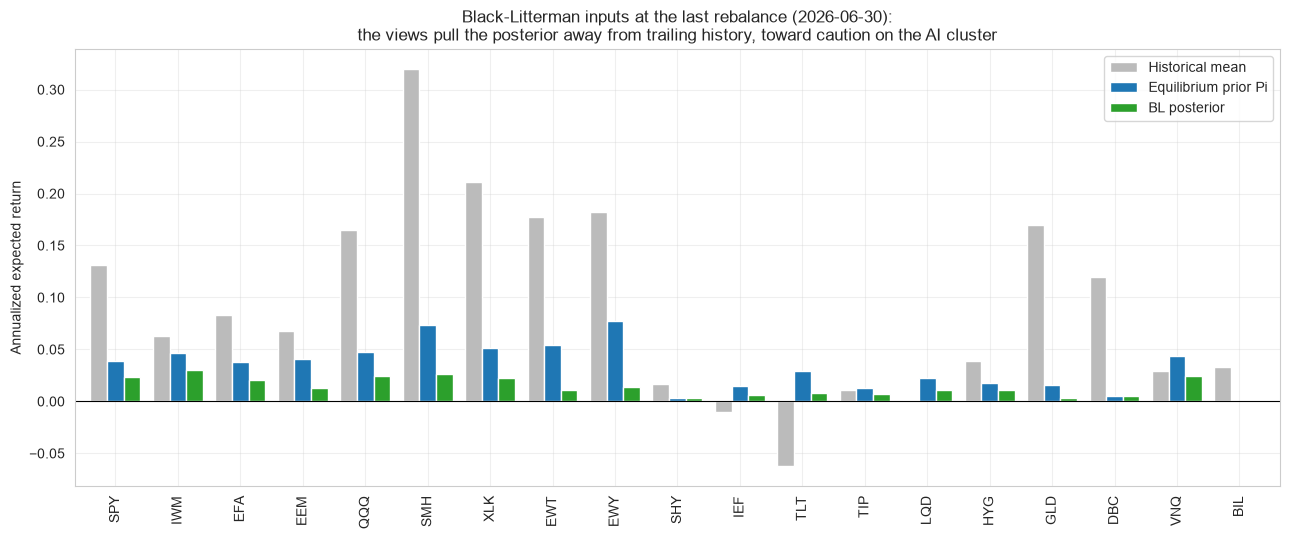

In [20]:
# What do the views actually do? Diagnostic at the last rebalance date:
# historical mean vs equilibrium prior vs BL posterior, per asset.
last_window = rets_m.iloc[rebalance_idx[-1] - WINDOW_MONTHS: rebalance_idx[-1]]
mu_hist, Sigma_last = estimate_mu_sigma(last_window, method=COV_METHOD)
mu_BL_last, _, Pi_last = black_litterman_posterior(mu_hist, Sigma_last)

diag = pd.DataFrame({'Historical mean': mu_hist, 'Equilibrium prior Pi': Pi_last,
                     'BL posterior': mu_BL_last}, index=asset_names)
fig, ax = plt.subplots(figsize=(13, 5.5))
diag.plot.bar(ax=ax, width=0.8, color=['#bbbbbb', '#1f77b4', '#2ca02c'])
ax.set_ylabel('Annualized expected return')
ax.set_title(f'Black-Litterman inputs at the last rebalance ({rebalance_dates[-1].date()}):\n'
             'the views pull the posterior away from trailing history, toward caution on the AI cluster')
ax.axhline(0, color='black', lw=0.8)
save_show('05_bl_posterior_vs_prior')

## 12. Benchmarks

Required by the assignment: at least one naive benchmark, rebalanced at the same
frequency, **plus** a benchmark representing the chosen universe itself.

- **60/40**: 60% `SPY` / 40% `IEF`, classic naive benchmark.
- **1/N**: equal-weight across all 19 ETFs, rebalanced monthly -- this *is* the "index
  representing the chosen universe" requested by the assignment.
- **100% QQQ** (reference only, not a real benchmark): shows what "just riding the AI
  rally" would have delivered, i.e. the concentration risk being actively managed by the
  three strategies above.

In [21]:
def strategy_6040(mu_hat, Sigma_hat):
    w = np.zeros(n)
    w[asset_names.index('SPY')] = 0.60
    w[asset_names.index('IEF')] = 0.40
    return w

def strategy_1n(mu_hat, Sigma_hat):
    return np.ones(n) / n

W_6040, ret_6040 = run_rolling_backtest(strategy_6040, '60/40 benchmark')
W_1n, ret_1n = run_rolling_backtest(strategy_1n, '1/N universe-index benchmark')
ret_qqq = rets_m['QQQ'].loc[ret_mkw.index]

60/40 benchmark: backtested 131 monthly periods over 131 rebalances
1/N universe-index benchmark: backtested 131 monthly periods over 131 rebalances


## 13. Out-of-sample performance measures

Cumulative return, annualized volatility, Sharpe (in excess of the realized T-bill return,
proxied by `BIL`), Sortino, max drawdown, Calmar, average turnover per rebalance, and
average portfolio concentration (Herfindahl-Hirschman Index, `HHI = sum(w_i^2)`:
1/19 = 0.053 is fully diversified, 1.0 is a single-asset portfolio).

In [22]:
rf_monthly = rets_m['BIL']   # realized T-bill return, used as the risk-free proxy

def perf_summary(ret, name):
    rf = rf_monthly.loc[ret.index]
    ann_ret = ret.mean() * MONTHS_PER_YEAR
    ann_rf = rf.mean() * MONTHS_PER_YEAR
    ann_vol = ret.std() * np.sqrt(MONTHS_PER_YEAR)
    sharpe = (ann_ret - ann_rf) / ann_vol
    excess = ret - rf
    downside = excess[excess < 0].std() * np.sqrt(MONTHS_PER_YEAR)
    sortino = (ann_ret - ann_rf) / downside if downside and downside > 0 else np.nan
    cum = (1 + ret).cumprod()
    dd = cum / cum.cummax() - 1
    max_dd = dd.min()
    calmar = ann_ret / abs(max_dd) if max_dd < 0 else np.nan
    return pd.Series({'Ann. Return': ann_ret, 'Ann. Vol': ann_vol, 'Sharpe': sharpe,
                      'Sortino': sortino, 'Max Drawdown': max_dd, 'Calmar': calmar}, name=name)

def turnover_avg(W_hist):
    return W_hist.diff().abs().sum(axis=1).mean()

def hhi_avg(W_hist):
    return (W_hist ** 2).sum(axis=1).mean()

strategies = {
    'Markowitz':            (ret_mkw, W_mkw),
    'Michaud':              (ret_mic, W_mic),
    'Black-Litterman':      (ret_bl, W_bl),
    '60/40':                (ret_6040, W_6040),
    '1/N (universe index)': (ret_1n, W_1n),
}

summary = pd.concat([perf_summary(r, name) for name, (r, w) in strategies.items()], axis=1)
summary['100% QQQ'] = perf_summary(ret_qqq, '100% QQQ')
summary.loc['Avg. Turnover'] = [turnover_avg(w) for name, (r, w) in strategies.items()] + [0.0]
summary.loc['Avg. HHI'] = [hhi_avg(w) for name, (r, w) in strategies.items()] + [1.0]
summary.T.round(3).to_csv(FIG_DIR / 'table_performance_summary.csv')
summary.T.style.format('{:.3f}')

,Ann. Return,Ann. Vol,Sharpe,Sortino,Max Drawdown,Calmar,Avg. Turnover,Avg. HHI
Markowitz,0.077,0.071,0.797,1.177,-0.172,0.445,0.147,0.185
Michaud,0.070,0.064,0.784,1.118,-0.167,0.420,0.111,0.123
Black-Litterman,0.077,0.116,0.487,0.622,-0.212,0.360,0.068,0.195
60/40,0.084,0.099,0.652,0.928,-0.216,0.390,0.000,0.520
1/N (universe index),0.093,0.108,0.678,0.935,-0.234,0.398,0.000,0.053
100% QQQ,0.180,0.188,0.852,1.320,-0.355,0.506,0.000,1.000


## 14. Equity curves, drawdown and rolling volatility

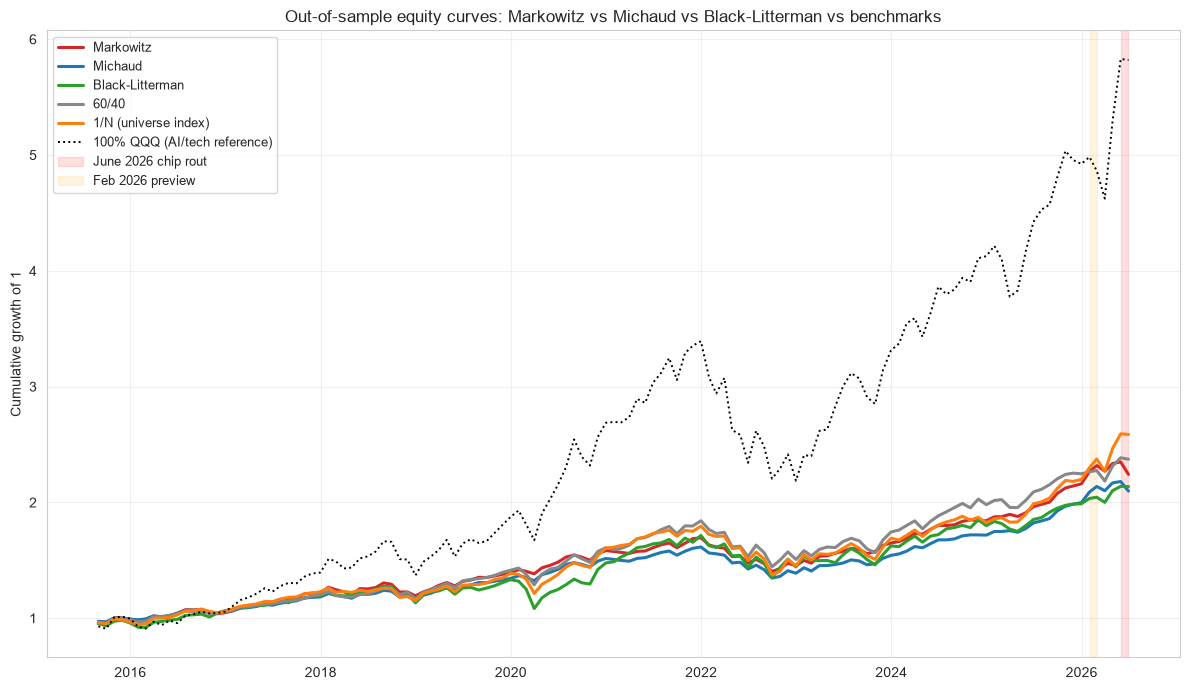

In [23]:
colors_map = {'Markowitz': '#d62728', 'Michaud': '#1f77b4', 'Black-Litterman': '#2ca02c',
             '60/40': '#888888', '1/N (universe index)': '#ff7f0e'}
STRESS_SPAN = (pd.Timestamp('2026-06-01'), pd.Timestamp('2026-06-30'))
PREVIEW_SPAN = (pd.Timestamp('2026-02-01'), pd.Timestamp('2026-02-28'))

fig, ax = plt.subplots(figsize=(12, 7))
for name, (r, w) in strategies.items():
    cum = (1 + r).cumprod()
    ax.plot(cum.index, cum.values, lw=2.2, label=name, color=colors_map.get(name))
cum_qqq = (1 + ret_qqq).cumprod()
ax.plot(cum_qqq.index, cum_qqq.values, lw=1.4, ls=':', color='black', label='100% QQQ (AI/tech reference)')
ax.axvspan(*STRESS_SPAN, color='red', alpha=0.12, label='June 2026 chip rout')
ax.axvspan(*PREVIEW_SPAN, color='orange', alpha=0.12, label='Feb 2026 preview')
ax.set_ylabel('Cumulative growth of 1')
ax.set_title('Out-of-sample equity curves: Markowitz vs Michaud vs Black-Litterman vs benchmarks')
ax.legend(loc='upper left', fontsize=9)
save_show('06_equity_curves')

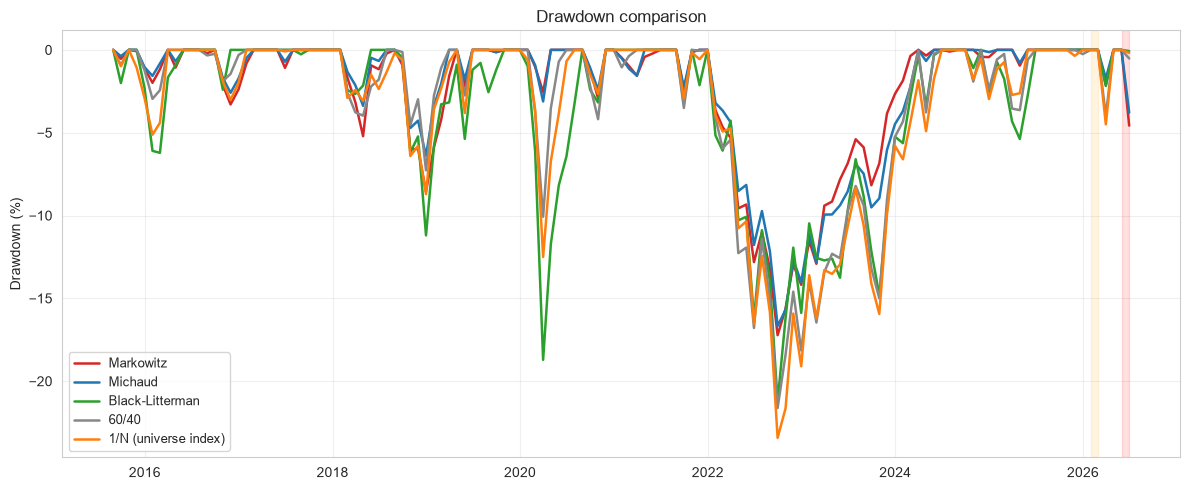

In [24]:
fig, ax = plt.subplots(figsize=(12, 5))
for name, (r, w) in strategies.items():
    cum = (1 + r).cumprod()
    dd = cum / cum.cummax() - 1
    ax.plot(dd.index, dd.values * 100, lw=1.8, label=name, color=colors_map.get(name))
ax.axvspan(*STRESS_SPAN, color='red', alpha=0.12)
ax.axvspan(*PREVIEW_SPAN, color='orange', alpha=0.12)
ax.set_ylabel('Drawdown (%)')
ax.set_title('Drawdown comparison')
ax.legend(loc='lower left', fontsize=9)
save_show('07_drawdowns')

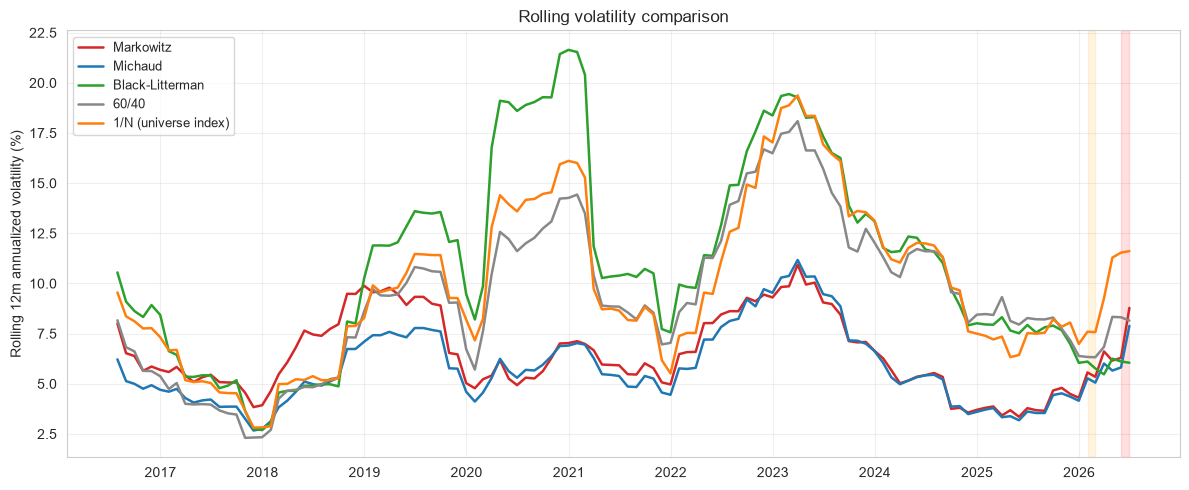

In [25]:
fig, ax = plt.subplots(figsize=(12, 5))
for name, (r, w) in strategies.items():
    roll_vol = r.rolling(12).std() * np.sqrt(MONTHS_PER_YEAR)
    ax.plot(roll_vol.index, roll_vol.values * 100, lw=1.8, label=name, color=colors_map.get(name))
ax.axvspan(*STRESS_SPAN, color='red', alpha=0.12)
ax.axvspan(*PREVIEW_SPAN, color='orange', alpha=0.12)
ax.set_ylabel('Rolling 12m annualized volatility (%)')
ax.set_title('Rolling volatility comparison')
ax.legend(loc='upper left', fontsize=9)
save_show('08_rolling_volatility')

## 15. Weight composition over time and AI-concentration diagnostics

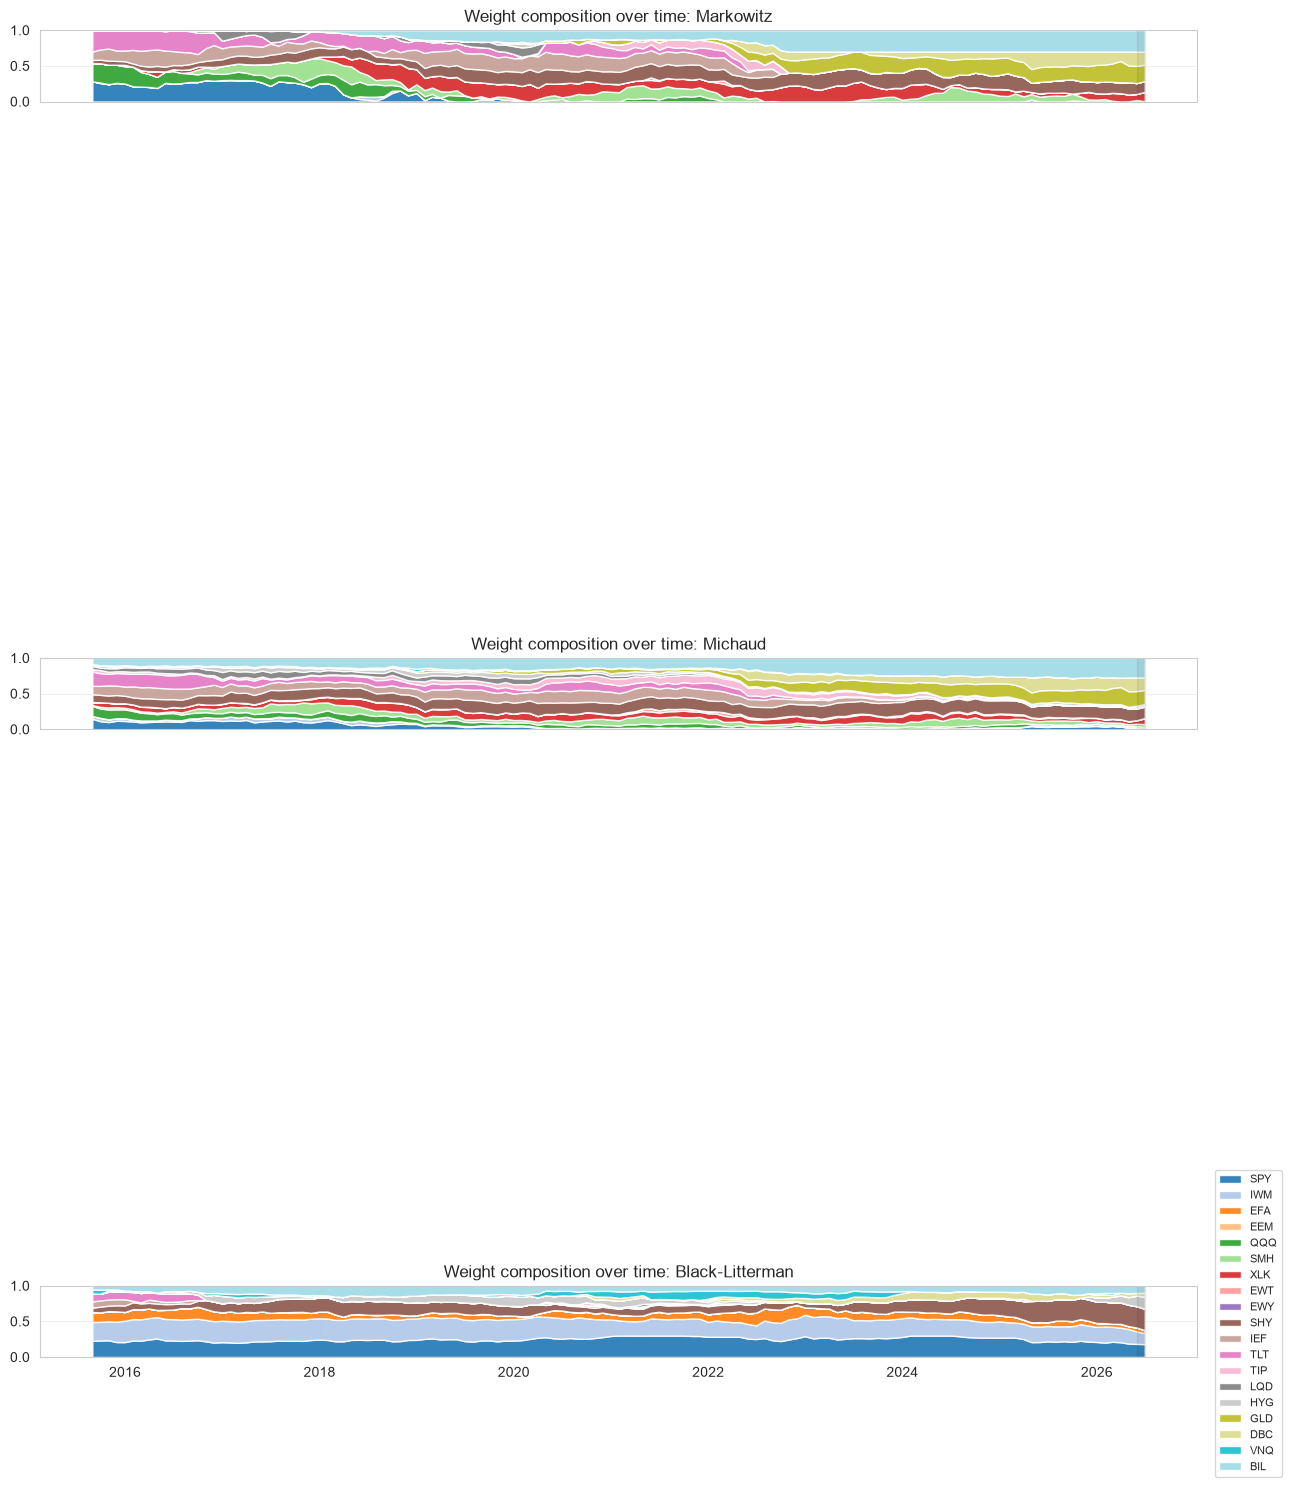

In [26]:
colors_assets = plt.cm.tab20(np.linspace(0, 1, n))
fig, axes = plt.subplots(3, 1, figsize=(13, 14), sharex=True)
for ax, (name, Wd) in zip(axes, [('Markowitz', W_mkw), ('Michaud', W_mic), ('Black-Litterman', W_bl)]):
    ax.stackplot(Wd.index, Wd.T.values.astype(float), labels=asset_names, colors=colors_assets, alpha=0.9)
    ax.set_ylim(0, 1)
    ax.set_title(f'Weight composition over time: {name}')
    ax.axvspan(*STRESS_SPAN, color='black', alpha=0.06)
axes[-1].legend(loc='upper left', bbox_to_anchor=(1.01, 2.7), fontsize=8)
save_show('09_weight_composition')

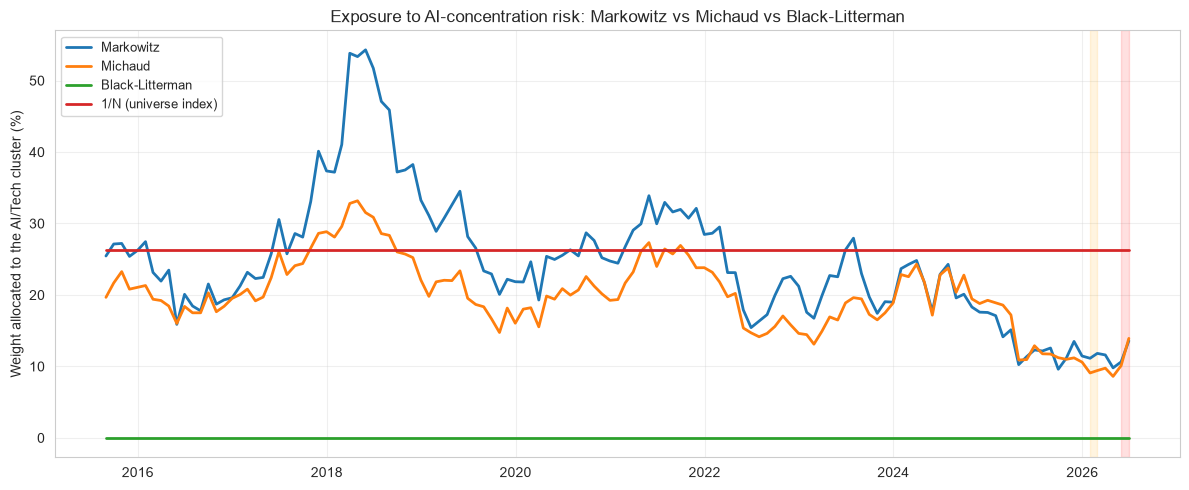

In [27]:
ai_cols = bucket_members['Equity_AI_Tech']
fig, ax = plt.subplots(figsize=(12, 5))
for name, Wd in [('Markowitz', W_mkw), ('Michaud', W_mic), ('Black-Litterman', W_bl), ('1/N (universe index)', W_1n)]:
    ai_weight = Wd[ai_cols].sum(axis=1)
    ax.plot(ai_weight.index, ai_weight.values * 100, lw=2, label=name)
ax.axvspan(*STRESS_SPAN, color='red', alpha=0.12)
ax.axvspan(*PREVIEW_SPAN, color='orange', alpha=0.12)
ax.set_ylabel('Weight allocated to the AI/Tech cluster (%)')
ax.set_title('Exposure to AI-concentration risk: Markowitz vs Michaud vs Black-Litterman')
ax.legend(loc='upper left', fontsize=9)
save_show('10_ai_cluster_weight')

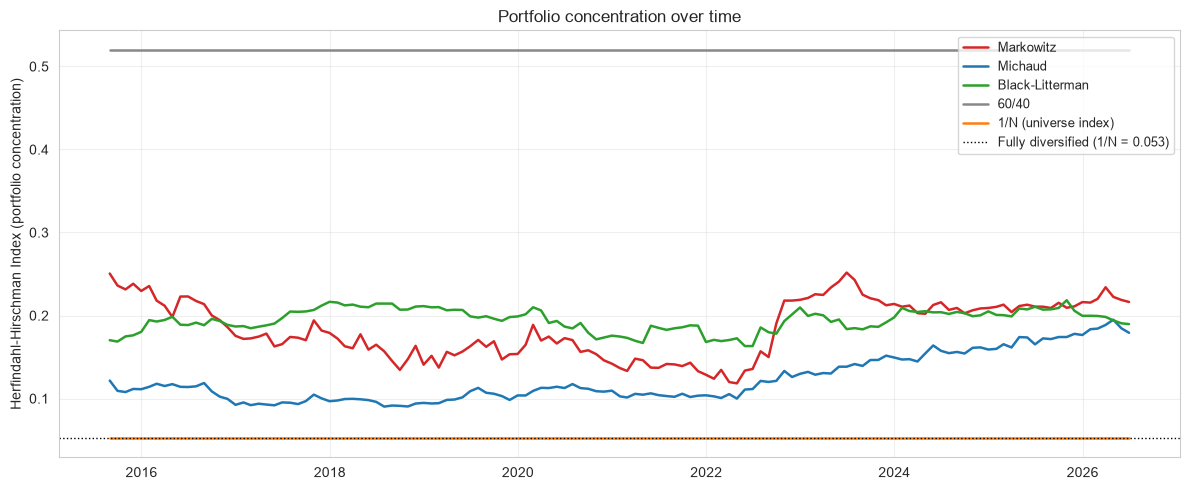

In [28]:
fig, ax = plt.subplots(figsize=(12, 5))
for name, (r, Wd) in strategies.items():
    hhi = (Wd ** 2).sum(axis=1)
    ax.plot(hhi.index, hhi.values, lw=1.8, label=name, color=colors_map.get(name))
ax.axhline(1 / n, color='black', lw=1, ls=':', label=f'Fully diversified (1/N = {1/n:.3f})')
ax.set_ylabel('Herfindahl-Hirschman Index (portfolio concentration)')
ax.set_title('Portfolio concentration over time')
ax.legend(loc='upper right', fontsize=9)
save_show('11_hhi_concentration')

## 16. Stress-window deep dive: February and June 2026

We isolate performance **only** over the stress windows documented in Section 4 — this is
the central empirical test of the project: does managing AI-concentration risk (Michaud /
Black-Litterman) actually pay off when the AI trade itself corrects?

Two resolutions:
1. **Monthly** (the frequency the strategies actually trade at): February and June 2026 as
   whole months.
2. **Daily zoom** with weights frozen at the last pre-shock rebalance, using the dated
   sub-windows from the event study — this reveals the intra-month severity that monthly
   data dilutes (the June crash partially recovered by month-end after Micron's earnings).

In [29]:
MONTHLY_WINDOWS = {
    'Feb 2026 (preview month)': ('2026-02-01', '2026-02-28'),
    'Jun 2026 (crisis month)':  ('2026-06-01', '2026-06-30'),
    'H1 2026':                  ('2026-01-01', '2026-06-30'),
}

def window_perf(ret, start, end, name):
    r = ret.loc[start:end]
    if len(r) == 0:
        return pd.Series({'Cum. Return': np.nan, 'Max Drawdown': np.nan}, name=name)
    cum = (1 + r).cumprod()
    dd = cum / cum.cummax() - 1
    return pd.Series({'Cum. Return': cum.iloc[-1] - 1, 'Max Drawdown': dd.min()}, name=name)

all_rets = {**{name: r for name, (r, w) in strategies.items()}, '100% QQQ': ret_qqq}
stress_tables = {}
for wname, (s, e) in MONTHLY_WINDOWS.items():
    stress_tables[wname] = pd.concat([window_perf(r, s, e, name) for name, r in all_rets.items()], axis=1).T

stress_all = pd.concat(stress_tables, axis=1)
stress_all.round(4).to_csv(FIG_DIR / 'table_stress_windows.csv')
print('Strategy performance in the 2026 stress windows (monthly resolution):')
display(stress_all.style.format('{:+.2%}'))

Strategy performance in the 2026 stress windows (monthly resolution):


**Reading the monthly-resolution limitation.** Because every strategy above is
rebalanced and measured monthly, the June 2026 shock -- concentrated in a handful of
sessions -- shows up as a single (possibly diluted) monthly observation: the crash of
23-24 June had partially recovered by month-end after Micron's earnings. The daily
zoom-in below freezes each strategy's last pre-shock weights and applies them to daily
returns during the stress windows, giving a sharper view of the shock's actual severity.

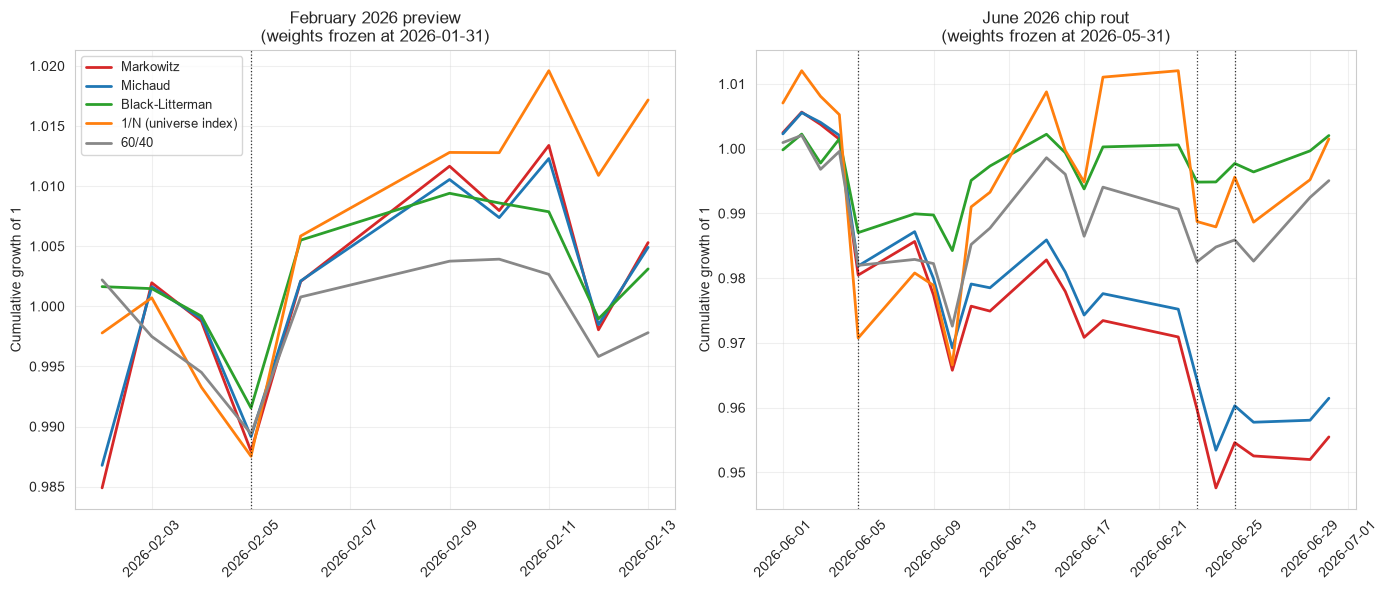

In [30]:
# Daily zoom on the two stress episodes, weights frozen at the last pre-shock rebalance.
strategy_weights = [('Markowitz', W_mkw), ('Michaud', W_mic), ('Black-Litterman', W_bl),
                    ('1/N (universe index)', W_1n), ('60/40', W_6040)]

daily_zoom_windows = {
    'February 2026 preview': ('2026-02-02', '2026-02-13'),
    'June 2026 chip rout':   ('2026-06-01', '2026-06-30'),
}

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
zoom_rows = []
for ax, (wname, (s, e)) in zip(axes, daily_zoom_windows.items()):
    last_rebal_before = rebalance_dates[rebalance_dates < s][-1]
    daily_rets_w = daily_simple.loc[s:e]
    for name, Wd in strategy_weights:
        w_frozen = Wd.loc[last_rebal_before].values.astype(float)
        daily_port_ret = daily_rets_w.values @ w_frozen
        cum = np.cumprod(1 + daily_port_ret)
        dd_min = (cum / np.maximum.accumulate(cum) - 1).min()
        zoom_rows.append({'Window': wname, 'Strategy': name,
                          'Cum. Return': cum[-1] - 1, 'Max Drawdown (daily)': dd_min})
        ax.plot(daily_rets_w.index, cum, lw=2, label=name, color=colors_map.get(name))
    for d in CRISIS_EVENTS:
        if s <= d <= e:
            ax.axvline(pd.Timestamp(d), color='black', lw=0.9, ls=':', alpha=0.8)
    ax.set_title(f'{wname}\n(weights frozen at {last_rebal_before.date()})')
    ax.set_ylabel('Cumulative growth of 1')
    ax.tick_params(axis='x', rotation=45)
axes[0].legend(fontsize=9)
save_show('12_stress_daily_zoom')

zoom_table = pd.DataFrame(zoom_rows).set_index(['Window', 'Strategy'])
zoom_table.round(4).to_csv(FIG_DIR / 'table_stress_daily_zoom.csv')
display(zoom_table.style.format('{:+.2%}'))

## 17. Conclusions

### Answering the research question

**1. Does robust construction reduce AI/tech concentration?** Yes, visibly. Michaud's
resampling cuts average portfolio concentration by a third relative to classical Markowitz
(avg HHI 0.123 vs 0.185) with lower turnover (0.111 vs 0.147 per rebalance), and the
weight-composition and AI-cluster charts (Section 15) show systematically smoother, less
extreme allocations. Black–Litterman anchors the portfolio to the strategic equilibrium and
trades the least of all (turnover 0.068).

**2. Did that pay off in the crisis?** In the **June 2026 crisis month** the ranking is
unambiguous: Black–Litterman was essentially flat (−0.1%; daily max drawdown −1.8%),
Michaud lost −3.8% (drawdown −5.2%), classical Markowitz −4.6% (drawdown −5.8%). Over the
whole of H1 2026 BL returned +7.5% with a −2.2% max drawdown, the best risk-adjusted
outcome of the three optimized strategies.

**3. The transmission channel was *not* the one you'd guess — and that is the point.**
At the last pre-crisis rebalance (2026-05-31) Markowitz held only ~14% in the AI/Tech
cluster, but 23% in gold and 18% in commodities — the trailing-window max-Sharpe had
chased the *previous* winners. In June the hawkish-Fed repricing that triggered the chip
rout also crashed gold (−11.7%) and commodities (−9.6%), while the chip crash itself
V-shaped back by month-end on Micron's earnings (QQQ closed June at −0.2%). So the
concentration that hurt was **estimation-driven momentum concentration**, and the rate
shock — driver 1 of Section 4.3 — was the channel. BL sailed through precisely because its
equilibrium prior refused to chase trailing winners and its duration view (SHY over TLT)
leaned against the rate shock.

**4. The honest full-sample trade-off.** Robustness was not free. Over the full
out-of-sample period (2015-08 → 2026-06) Markowitz and Michaud deliver almost identical
Sharpe ratios (0.80 vs 0.78) — resampling achieved the *same* risk-adjusted return with a
much more diversified, cheaper-to-trade portfolio, which is exactly Michaud's (1989) claim.
BL's permanently cautious views cost real carry during the 2023–25 AI rally (full-sample
Sharpe 0.49). And the passive 100% QQQ reference — maximum concentration — still ends the
sample with the highest Sharpe (0.85), at the price of a −35.5% max drawdown vs −17% for
the optimized strategies: riding concentration paid *on average* over this bull-heavy
sample, but with tail risk that only shows its teeth in windows like June 2026 (and that a
longer or less favourable sample would price very differently).

### Takeaways for the presentation

- Estimation error, not the AI theme per se, is what classical Markowitz concentrates on;
  resampling fixes the *symptom* (concentration, turnover) at no Sharpe cost.
- Economically grounded BL views are the only construction that actually *protected* in
  the stress windows — but constant cautionary views are an insurance premium paid every
  month of the rally.
- Stress windows must be analysed at daily resolution: at monthly resolution the June
  chip rout almost disappears from equity ETFs (V-shaped recovery) and survives only
  through the gold/commodity leg.

**Robustness.** All headline conclusions are re-examined in
`02_sensitivity_analysis.ipynb`: estimation window (36/60/84 months), covariance
treatment (sample vs Ledoit-Wolf), weight cap, quarterly rebalancing, BL `tau` and view
magnitudes, and an explicit AI-bucket budget constraint (max 25%) as the "direct"
alternative to letting the optimizer manage concentration.
